<a href="https://colab.research.google.com/github/Kotyga/ML_toolkit/blob/main/Gabriel_Graph_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -qqq datasets sentence_transformers transformers nolds

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.7/225.7 kB 1.1 MB/s eta 0:00:00


In [2]:
import random
import numpy as np
from sklearn.decomposition import TruncatedSVD
from sentence_transformers import SentenceTransformer, util
from datasets import load_dataset
import itertools
import networkx as nx

from scipy.spatial import Delaunay
from scipy.spatial import Voronoi, voronoi_plot_2d
import matplotlib.pyplot as plt
import nolds

import pandas as pd
import warnings
warnings.simplefilter("ignore")

In [3]:
def build_word_document_matrix(corpus, model):
    embeddings = model.encode(corpus, convert_to_tensor=True)
    return embeddings.cpu().numpy()

In [4]:
def perform_svd(matrix, n_components=2):
    svd = TruncatedSVD(n_components=n_components)
    U = svd.fit_transform(matrix)
    S = svd.singular_values_
    return U, S

In [5]:
def assign_word_vectors(matrix, U):
    word_vectors = {}
    for i, vector in enumerate(U):
        word_vectors[f'word_{i}'] = vector
    return word_vectors

In [6]:
def represent_text_as_time_series(word_vectors):
    time_series = np.array(list(word_vectors.values()))
    return time_series

In [7]:
texts = [
    "At dawn the castle corridors smelled of wax and rain, and the portraits pretended to sleep as students hurried to class.",
    "He traced the runes on the old map and felt the ink warm, as if the parchment remembered every secret passage.",
    "In the candlelit library, a forbidden volume sighed open, releasing a thin spiral of dust like a whispered warning.",
    "The owl arrived late, feathers damp with storm, and dropped a letter sealed in green wax that pulsed faintly in his palm.",
    "She practiced the charm again and again until sparks became steady light, and the room finally stopped trembling.",
    "A hidden staircase rotated with a groan, revealing a door that had never existed on any floor plan of the tower.",
    "The potion simmered to a pearly sheen; one careless stir would turn it bitter and wake the whole dungeon with fumes.",
    "He heard footsteps behind him, but when he turned there was only a draft and the soft giggle of a mischievous spirit.",
    "On the pitch, the wind snapped the banners and the crowd roared as a glint of gold darted between the clouds.",
    "The headmaster’s gaze was gentle but unblinking, like a lantern held over a deep well of questions.",
    "She folded the cloak around her shoulders, and the world slipped away as if she’d stepped behind the idea of herself.",
    "A silver animal of light burst from his wand, ran across the floor, and vanished through the wall to deliver its message.",
    "The corridor grew colder with each step, and their breath fogged into pale ghosts that drifted toward the ceiling.",
    "He swore the mirror watched him back, not with eyes, but with the patience of a thing that knew his future.",
    "Their friendship felt like a spell cast quietly—no thunder, just a steady warmth that held through dark weeks.",
    "The forest edge was a line of black needles against the moon, and every rustle sounded like a name being spoken.",
    "She pocketed the enchanted coin; minutes later it warmed, and the tiny marks rearranged into urgent instructions.",
    "The train windows flashed with village lights, and for a moment he imagined a normal life stitched into the passing dark.",
    "A professor’s chalk moved on its own, sketching diagrams of constellations that didn’t belong to any known sky.",
    "He tasted fear like metal on his tongue, then forced himself to breathe until courage returned, quiet and stubborn.",
    "The spell backfired into a shower of harmless butterflies, and the class laughed until even the stern teacher relented.",
    "A diary with too many blank pages lay in the trunk, and when she touched it, her fingertips tingled with unease.",
    "The gargoyle at the stairway muttered riddles, and the right answer felt less like logic and more like listening.",
    "In the common room, the fire snapped and the shadows danced, making heroes of ordinary chairs and tired faces.",
    "He kept the broken wand as a reminder that power without care is just another kind of accident.",
    "The lake was flat as polished stone, yet something far below shifted, slow and ancient, like a thought waking.",
    "She learned the counter-curse from a smudged note in the margins, written by someone who’d been desperate before.",
    "A secret society met after curfew, not for glory, but to practice being brave in small, repeatable ways.",
    "The staircase tried to throw them off, but they moved together, laughing, as if mischief were a shared language.",
    "A phoenix feather quivered in the wand, and the air smelled briefly of smoke and clean beginnings.",
    "He wrote home carefully, leaving out the terrifying parts, and wondering if love was always a kind of editing.",
    "The snow fell in silence, frosting statues and turning the battlements into a postcard that hid its sharp edges.",
    "A suit of armor bowed as they passed, then winked—just once—like it approved of their plan.",
    "She discovered that some doors open only when you admit, out loud, what you’re afraid to find inside.",
    "The forbidden corridor wasn’t guarded by locks so much as by dread, which clung to the stones like mildew.",
    "He listened to the ghosts argue about centuries-old gossip, amazed that even eternity didn’t cure pettiness.",
    "A spark from the fireplace spelled his name in ash, and he knew the evening was about to become complicated.",
    "The spellbook demanded a blood signature; she refused, and the pages turned spitefully, as if offended by boundaries.",
    "They brewed tea that tasted of peppermint and relief, and for an hour the war felt far enough away to breathe.",
    "The duel was less about strength than timing; one honest step forward changed everything.",
    "A charm meant for candles lit the whole hallway, revealing scratches in the wall like counting marks of prisoners.",
    "He watched the stars and wondered who first decided that constellations were stories rather than accidents.",
    "The courtyard echoed with laughter, but underneath it ran a thin current of worry, persistent as a drumbeat.",
    "A dragon’s shadow crossed the tents, and every conversation stopped mid-syllable, as if the world held its breath.",
    "She found a note inside her textbook: “Trust your instincts, not your pride,” signed by no one.",
    "The corridor clock chimed thirteen, and for a heartbeat the portraits looked away, embarrassed by time’s mistake.",
    "He carried a small charm in his pocket, not for magic, but for the memory of someone who believed in him.",
    "The final exam wasn’t written on parchment, but on their nerves; passing meant choosing kindness under pressure.",
    "When the storm ended, the castle smelled of wet stone and possibility, as if the night had washed the fear clean.",
    "The patient arrived febrile with hypotension and tachypnea; sepsis protocol was initiated with lactate trending and blood cultures drawn.",
    "ECG showed ST-segment elevation in the inferior leads; aspirin, heparin, and emergent cath lab activation followed.",
    "ABG revealed hypoxemia with respiratory alkalosis, consistent with early pulmonary embolism in the context of pleuritic pain.",
    "CT head without contrast ruled out acute hemorrhage before thrombolysis was considered for suspected ischemic stroke.",
    "The CBC demonstrated neutrophilic leukocytosis and left shift; empiric coverage targeted likely community-acquired pneumonia.",
    "Creatinine rose sharply after contrast exposure; we suspected contrast-associated AKI and optimized fluids while holding nephrotoxins.",
    "Urinalysis showed proteinuria and dysmorphic RBCs, raising concern for glomerulonephritis; nephrology was consulted for biopsy planning.",
    "Point-of-care ultrasound identified a plethoric IVC and B-lines, supporting acute decompensated heart failure as the cause of dyspnea.",
    "Troponin was mildly elevated without dynamic change, suggesting demand ischemia rather than type 1 myocardial infarction.",
    "The patient’s INR was supratherapeutic on warfarin; vitamin K was administered and bleeding risk reassessed.",
    "D-dimer was elevated but nonspecific; we proceeded to CTPA based on pretest probability and Wells criteria.",
    "LFTs showed cholestatic pattern with elevated ALP and bilirubin; ultrasound evaluated for biliary obstruction.",
    "Blood glucose remained persistently >300 mg/dL; basal-bolus insulin was initiated with correctional dosing and electrolyte monitoring.",
    "TSH was suppressed with elevated free T4; beta-blockade and antithyroid therapy were started for symptomatic thyrotoxicosis.",
    "Sodium was 118 mmol/L with low serum osmolality; fluid restriction and careful correction were used to avoid osmotic demyelination.",
    "Potassium was 6.4 mmol/L with peaked T waves; calcium gluconate, insulin-dextrose, and loop diuretics were administered urgently.",
    "The patient reported melena and dizziness; hemoglobin trended down and endoscopy was planned after hemodynamic stabilization.",
    "Chest X-ray demonstrated lobar consolidation; antibiotics were narrowed after sputum culture sensitivities returned.",
    "MRI spine revealed epidural abscess; neurosurgery was alerted given evolving neurologic deficits and cord compression risk.",
    "A new systolic murmur with fever prompted evaluation for infective endocarditis including TEE and serial blood cultures.",
    "Lower extremity Doppler ultrasound confirmed DVT; anticoagulation was initiated with bleeding precautions and follow-up plan.",
    "Spirometry demonstrated obstructive physiology with bronchodilator reversibility, supporting asthma rather than fixed COPD.",
    "Peak flow improved after nebulized albuterol; an oral steroid burst was prescribed with inhaler technique counseling.",
    "The patient developed postoperative atelectasis; incentive spirometry and early ambulation were emphasized.",
    "RUQ tenderness with positive Murphy sign and leukocytosis suggested acute cholecystitis; surgery evaluated for cholecystectomy.",
    "Lipase was markedly elevated with epigastric pain radiating to the back; pancreatitis management focused on fluids and analgesia.",
    "Peripheral smear showed schistocytes with thrombocytopenia; TTP was suspected and plasma exchange arranged emergently.",
    "Macrocytosis with low B12 explained paresthesias; replacement therapy was started with neurologic monitoring.",
    "The rash with target lesions after a new medication raised concern for Stevens–Johnson syndrome; the drug was stopped and burn unit consulted.",
    "Joint aspiration revealed negatively birefringent crystals, consistent with gout; NSAIDs were considered with renal function in mind.",
    "CRP and ESR were elevated in temporal headache with jaw claudication; steroids were initiated for suspected giant cell arteritis.",
    "A1c returned at 9.8%; diabetes education emphasized diet, activity, and medication adherence with scheduled follow-up.",
    "The patient’s anemia was microcytic with low ferritin; iron deficiency workup included occult blood testing and colonoscopy planning.",
    "New-onset atrial fibrillation with RVR required rate control and CHA2DS2-VASc scoring for anticoagulation decision-making.",
    "Orthostatic vitals were positive; dehydration and medication effects were reviewed, and IV fluids improved symptoms.",
    "Severe headache with neck stiffness prompted lumbar puncture; CSF pleocytosis supported bacterial meningitis treatment.",
    "Skin and soft tissue infection with fluctuance required incision and drainage alongside MRSA-active antibiotics.",
    "In pregnancy with hypertension and proteinuria, preeclampsia was suspected; magnesium prophylaxis and fetal monitoring were initiated.",
    "Postpartum hemorrhage management escalated from uterotonics to tranexamic acid with quantification of blood loss.",
    "The patient’s oxygen requirement increased; repeat imaging assessed for ARDS and ventilator settings were adjusted to lung-protective strategy.",
    "A central line was placed under ultrasound guidance; sterile technique and post-procedure chest X-ray confirmed position.",
    "Blood cultures grew gram-positive cocci in clusters; vancomycin was continued pending speciation and susceptibilities.",
    "Persistent diarrhea after antibiotics raised suspicion for C. difficile; toxin testing guided oral vancomycin therapy.",
    "The patient exhibited delirium with fluctuating attention; we addressed triggers, optimized sleep, and avoided deliriogenic meds.",
    "A new diabetic foot ulcer required debridement, offloading, vascular assessment, and targeted antimicrobial therapy.",
    "Peripheral edema and foamy urine suggested nephrotic syndrome; albumin was low and lipid profile was elevated.",
    "Hepatitis serologies clarified chronic infection status; counseling covered transmission risk and antiviral treatment options.",
    "Anaphylaxis with wheeze and hypotension was treated with intramuscular epinephrine, airway assessment, and observation for biphasic reaction.",
    "After syncope, telemetry captured ventricular ectopy; cardiology evaluated for structural disease and arrhythmia management."
]

In [8]:
def ccw(A,B,C):
    return (C[1]-A[1]) * (B[0]-A[0]) > (B[1]-A[1]) * (C[0]-A[0])

In [9]:
def intersect(A,B,C,D):
    return ccw(A,C,D) != ccw(B,C,D) and ccw(A,B,C) != ccw(A,B,D)

In [10]:
def DelaunayGraph(points, info=None):
    tri = Delaunay(points)
    G = nx.Graph()

    indptr = tri.vertex_neighbor_vertices[0]
    indices = tri.vertex_neighbor_vertices[1]
    for i in range(len(points)):
        for j in indices[indptr[i]:indptr[i+1]]:
            if i < j:
                G.add_edge(i, j)
                if info != None:
                  G.add_node(i, node_class=info[i])
    return G

In [11]:
def GabrielViaDelaunayVoronoi(points, classes=None, info=None):
    delaunayGraph = DelaunayGraph(points, info)
    voronoiDiagram = Voronoi(points)
    voronoiVertices = voronoiDiagram.vertices
    voronoiCenter = voronoiDiagram.points.mean(axis=0)
    ptp_bound = np.ptp(voronoiDiagram.points, axis=0)

    gabrielGraph = nx.Graph()
    for u, v in delaunayGraph.edges():
        uRegion = set(voronoiDiagram.regions[voronoiDiagram.point_region[u]])
        vRegion = set(voronoiDiagram.regions[voronoiDiagram.point_region[v]])
        boundary = sorted(list(uRegion.intersection(vRegion)))[-2:]
        boundaryVertices = [None, voronoiVertices[boundary[1]]]

        if (boundary[0] == -1):
            tangent = points[u] - points[v]
            tangent /= np.linalg.norm(tangent)
            normal = np.array([-tangent[1], tangent[0]])

            midPoint = 0.5 * (points[u] + points[v])
            direction = np.sign(np.dot(midPoint - voronoiCenter, normal)) * normal
            farPoint = voronoiVertices[boundary[1]] + direction * ptp_bound.max()
            boundaryVertices[0] = farPoint
        else:
            boundaryVertices[0] = voronoiVertices[boundary[0]]

        if intersect(points[u], points[v], boundaryVertices[0], boundaryVertices[1]):
            gabrielGraph.add_edge(u, v)
    if info != None:
      for i in delaunayGraph.nodes():
        if gabrielGraph.has_node(i):
          if 'node_class' in delaunayGraph.nodes()[i].keys():
            gabrielGraph.add_node(i, node_class=delaunayGraph.nodes()[i]['node_class'])

    unique_classes = list(set(classes))
    colors = plt.cm.get_cmap('viridis', len(unique_classes))
    color_map = {cls: colors(i) for i, cls in enumerate(unique_classes)}

    node_colors = [color_map[classes[i]] for i in range(len(classes))]

    plt.figure(figsize=(10, 8))
    plt.title("Gabriel Graph via Delaunay and Voronoi", fontsize=16)

    pos = {i: points[i] for i in range(len(points))}
    nx.draw_networkx_nodes(gabrielGraph, pos, node_size=50, node_color=node_colors, alpha=0.7)
    nx.draw_networkx_edges(gabrielGraph, pos, width=0.5, alpha=0.5)
    plt.axis('equal')
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.grid(True)
    plt.tight_layout()

    # plt.savefig("GabrielDV.png", dpi=300)
    plt.show()
    return gabrielGraph

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

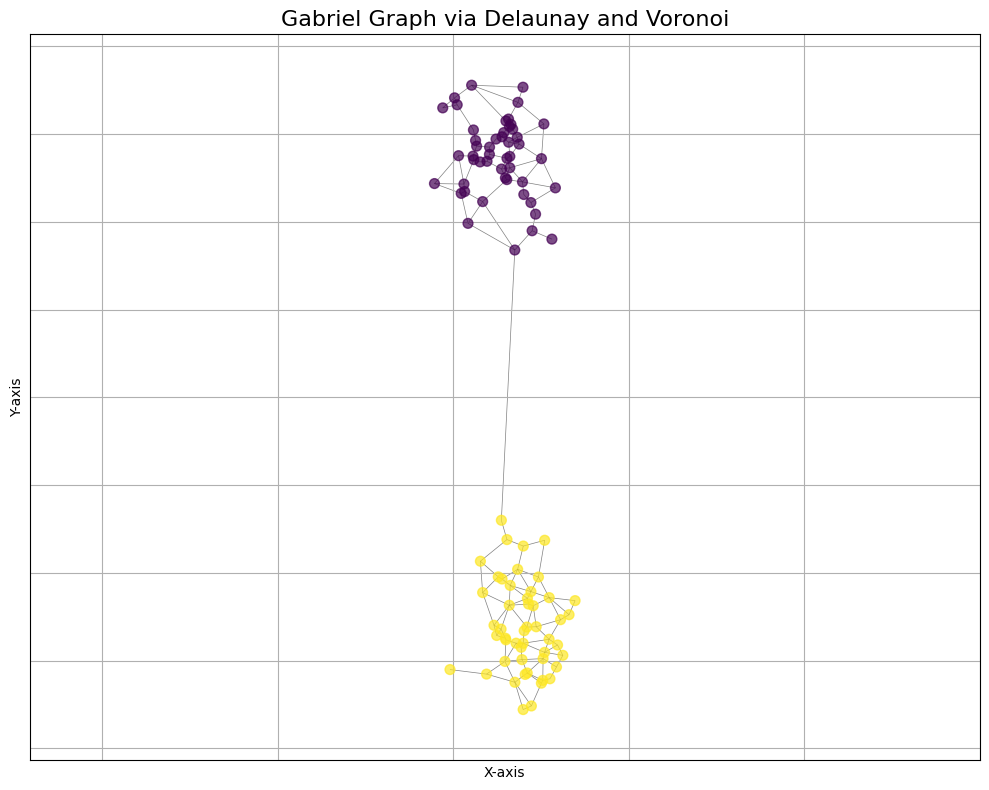

In [12]:
model = SentenceTransformer('BAAI/bge-m3')
matrix = build_word_document_matrix(texts, model)
U, S = perform_svd(matrix, 2)
word_vectors = assign_word_vectors(matrix, U)
time_series = represent_text_as_time_series(word_vectors)
classes = [0]*49 + [1]*49
GabrielViaDelaunayVoronoi(time_series, classes)